Import all of the neccesary stuff

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, zero_one_loss
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn import preprocessing 
import math
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import precision_recall_curve

Get the data from the csv file

In [2]:
data = pd.read_csv(r"C:\Users\calhe\Desktop Backup\Work Stuff\Uni\Year 3\CMP310 AI\CK-features.csv")
print(data.head())
print(data.shape)

  emotion   x0   y0   x1   y1   x2   y2   x3   y3   x4  ...  x66  y66  x67  \
0     joy  217  236  219  265  223  294  228  324  238  ...  333  341  319   
1     joy  195  214  198  244  201  273  204  303  213  ...  299  319  287   
2     joy  227  180  228  207  231  232  233  259  240  ...  333  279  319   
3     joy  189  176  191  205  193  233  195  262  205  ...  300  286  283   
4     joy  185  232  188  261  191  289  196  319  205  ...  302  330  287   

   y67  leftBrow  rightBrow  leftLip  rightLip  lipHeight  lipWidth  
0  340     5.926      5.864    5.550     6.335      5.196     2.889  
1  318     6.095      5.841    5.668     5.918      5.027     2.708  
2  277     6.170      6.308    7.515     7.100      6.829     2.965  
3  284     5.920      5.868   10.332     9.849      9.882     4.243  
4  328     5.645      5.781    5.004     4.951      3.959     2.229  

[5 rows x 143 columns]
(447, 143)


In [3]:
#Convert each emotion to an Integer
emotion_map = {
    "joy": 1,
    "disgust": 2,
    "surprise": 3,
    "sadness": 4,
    "anger": 5,
    "fear": 6
}
data["emotion"] = data["emotion"].map(emotion_map)

EDA

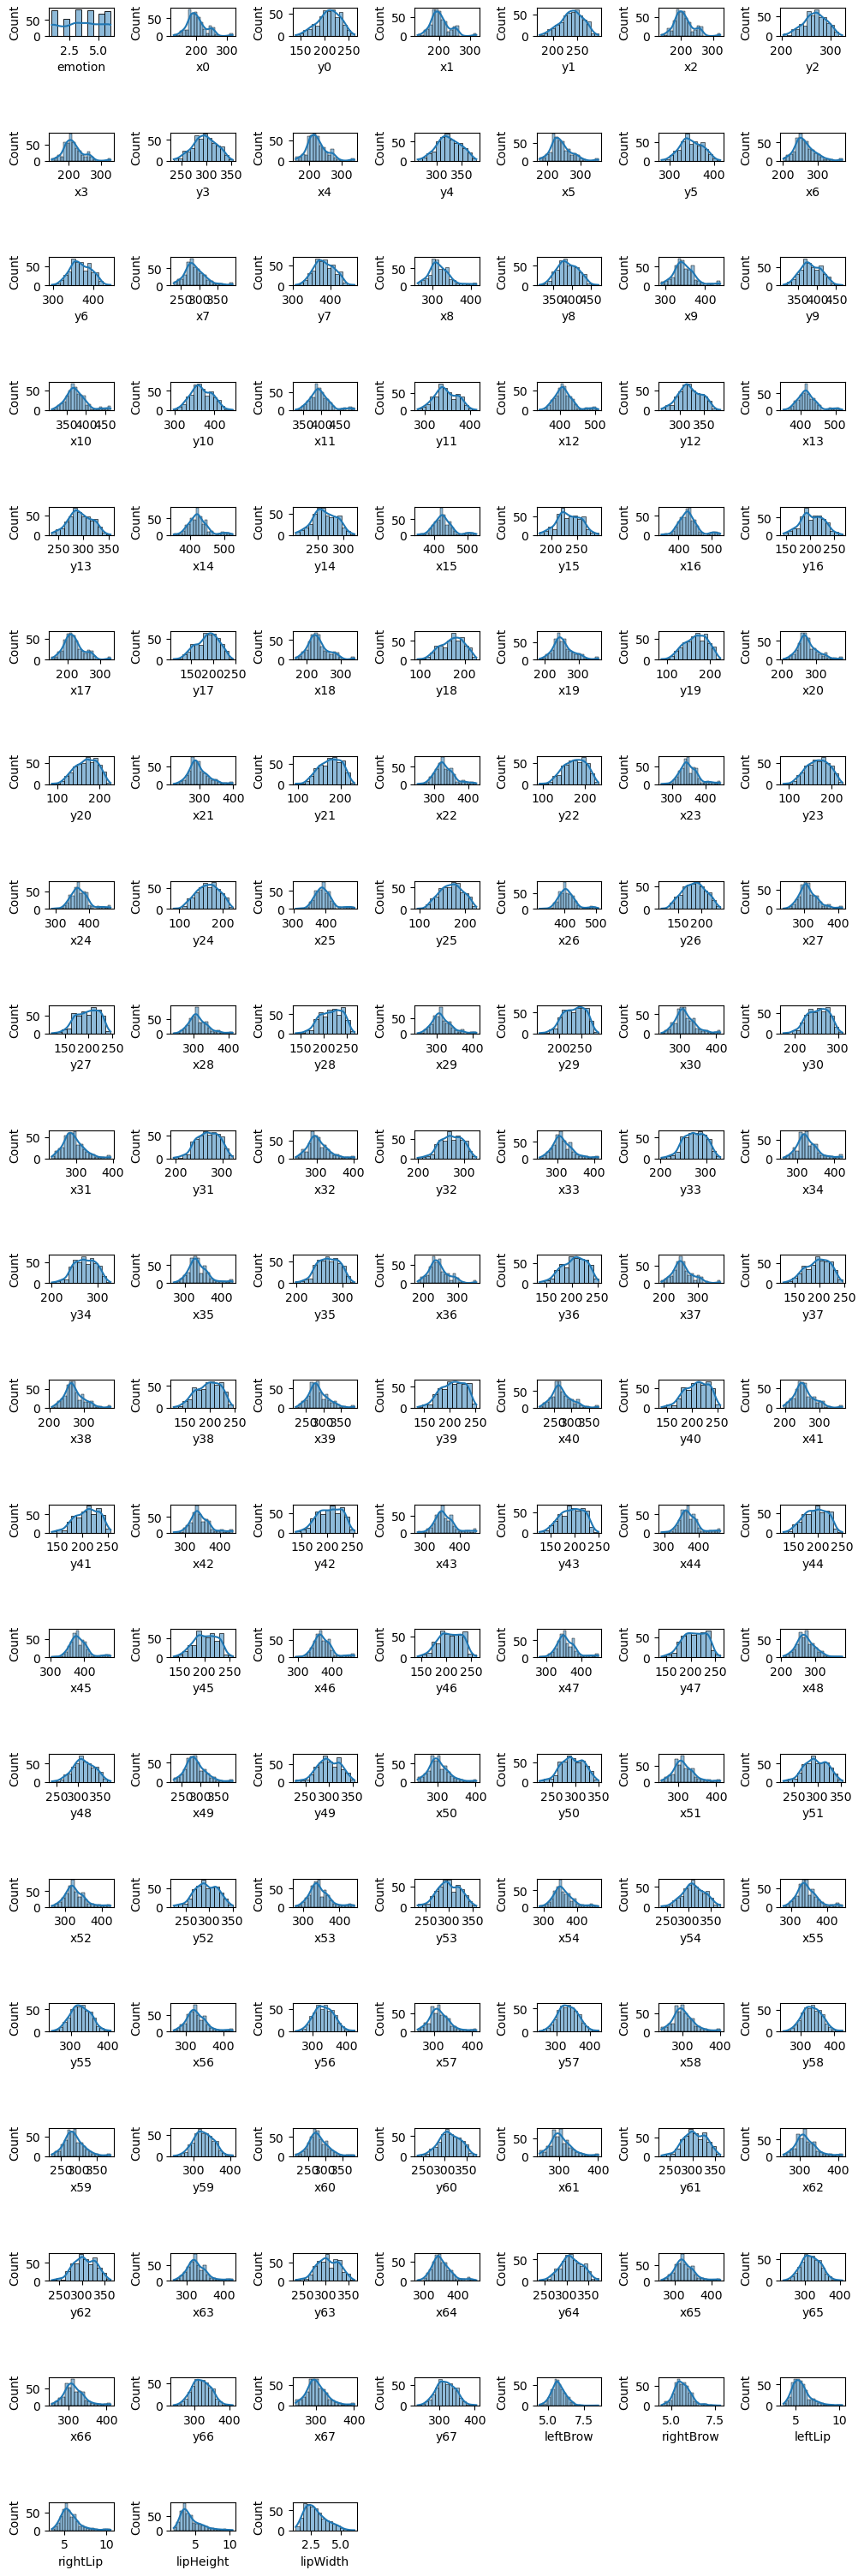

In [4]:
#Histogram

# Create subplots - Adjust ncols and nrows based on the number of features
ncols = 7  # Number of columns in the subplot grid
nrows = (len(data.columns) // ncols) + 1  # Calculate rows based on the number of columns
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(10, 30))
axs = axs.flatten()

# Plotting the histograms for each feature
for i, fn in enumerate(data.columns):
    sns.histplot(data[fn], ax=axs[i], kde=True)

# Remove any unused subplots if there are any
for i in range(len(data.columns), len(axs)):
    fig.delaxes(axs[i])

# Adjust plot dimensions and scale for better visualization
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

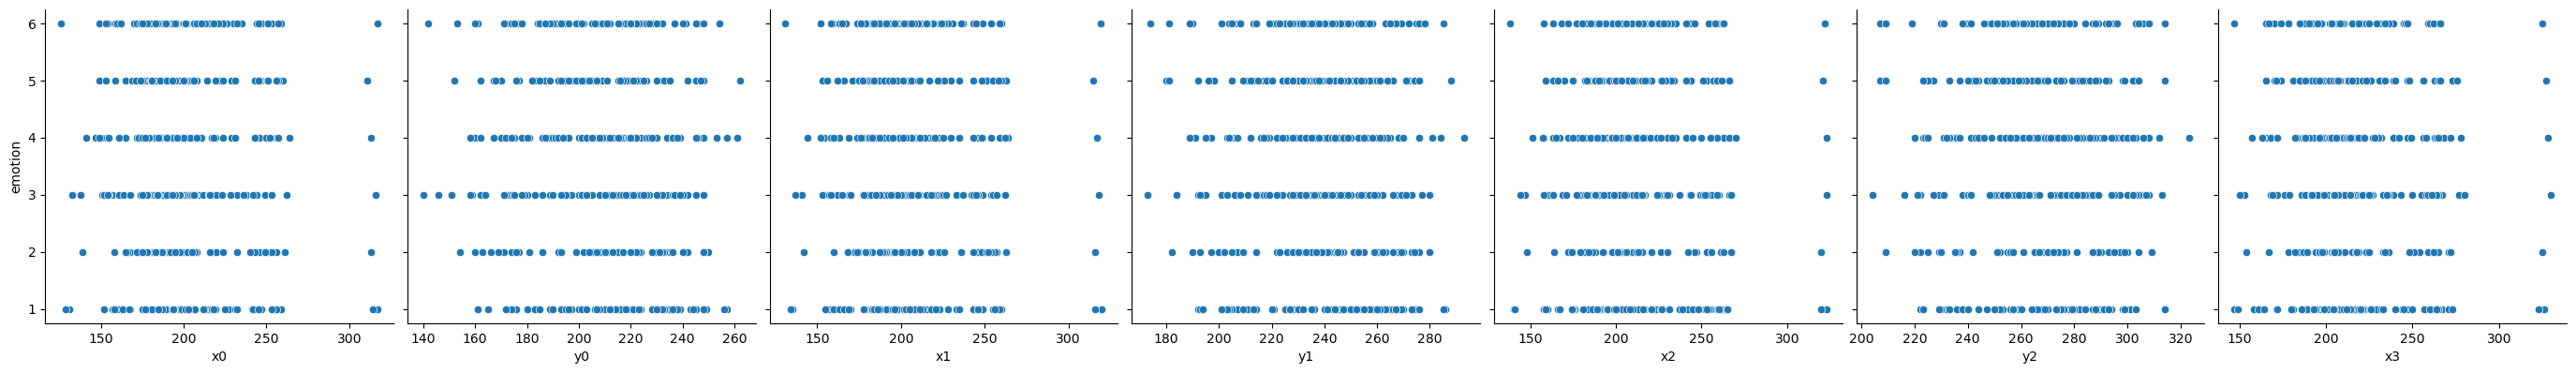

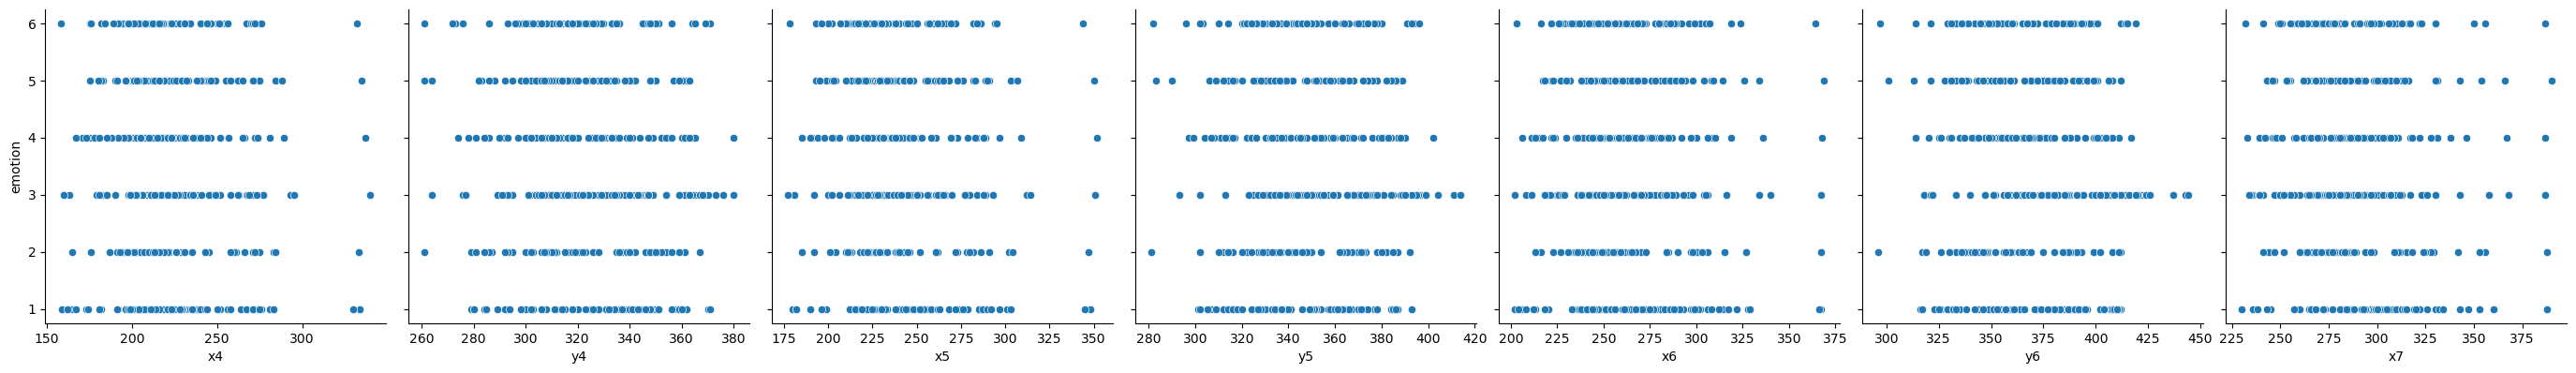

In [ ]:
#Loop through the first coordinate pairs and plot a pairplot for each feature, 8 plots per row
for i in range(1, 16, 8):
    sns.pairplot(data=data, y_vars=["emotion"], x_vars=data.columns[i: i+7], height=4);

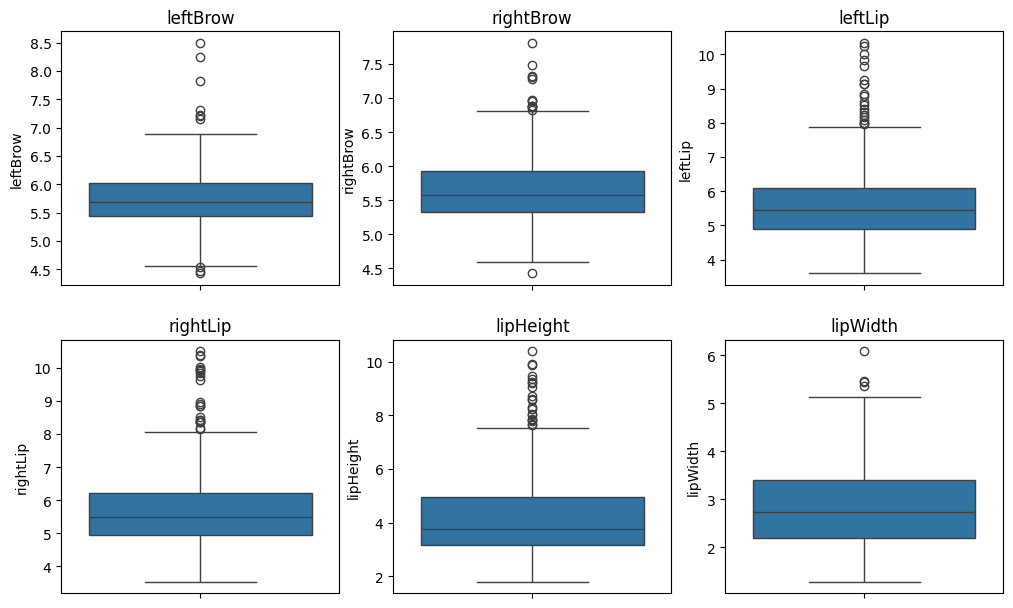

In [982]:
#Plot a set of boxplots for a set of 6 features
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(10, 6))  
last_features = list(data.items())[-6:]  

for ax, (fn, fd) in zip(axs.ravel(), last_features):
    sns.boxplot(y=fd, ax=ax)
    ax.set_title(fn)

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)

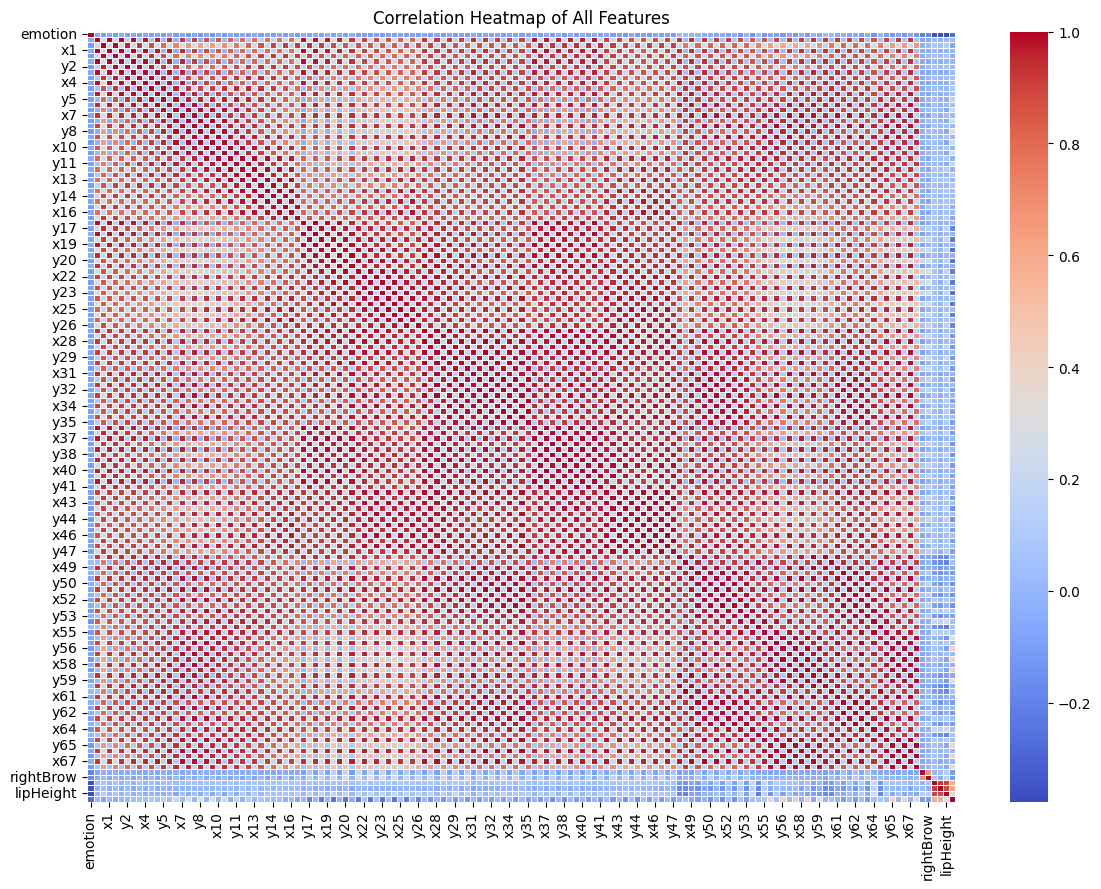

In [983]:
# Calculate the full correlation matrix for all features
corr_matrix = data.corr()

# Create the heatmap for all feature correlations
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)

# Add a title
plt.title('Correlation Heatmap of All Features')

# Display the plot
plt.show()

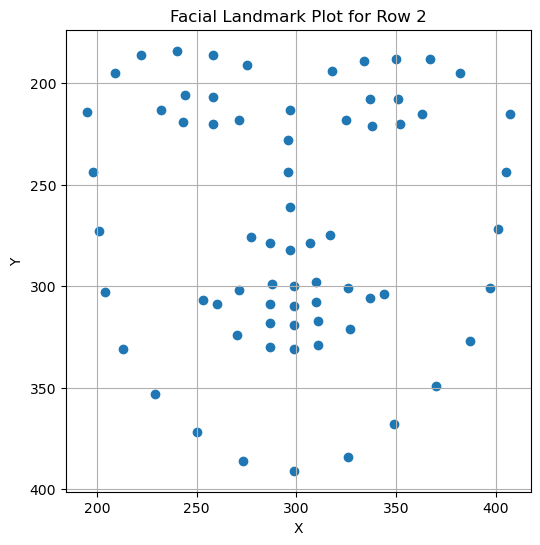

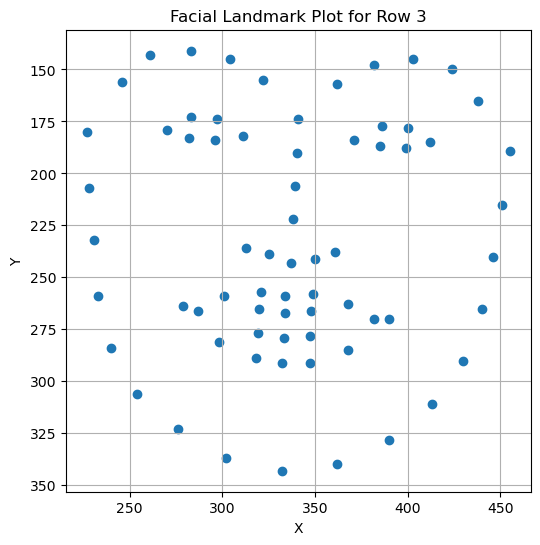

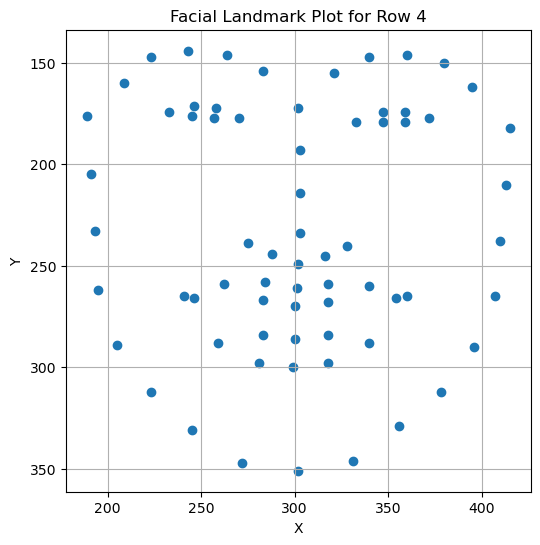

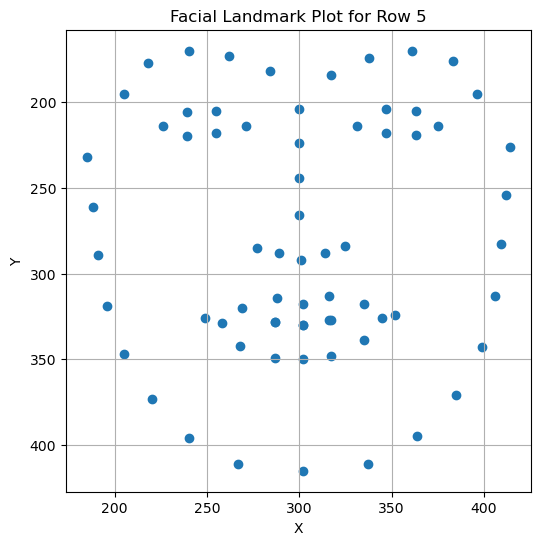

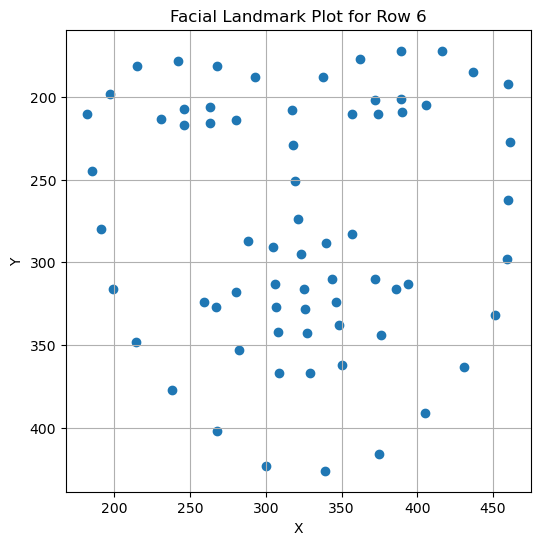

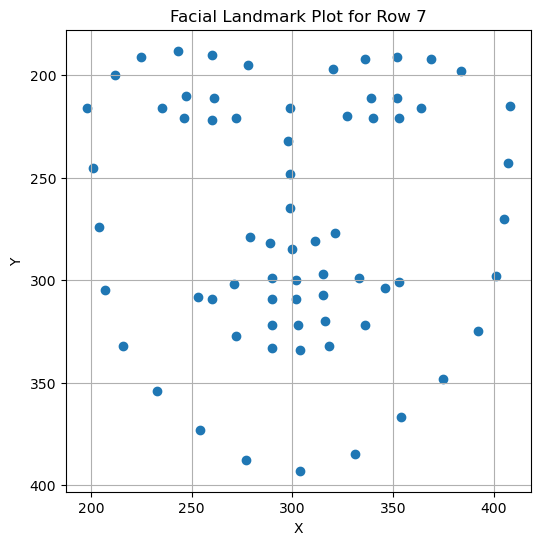

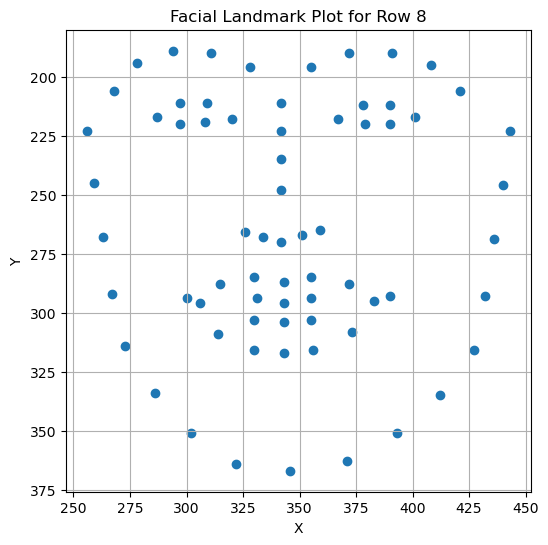

In [9]:
#Plot The first 16 faces
import matplotlib.pyplot as plt

#Loop through the first 8 faces
for x in range(1, 8):
    row = data.iloc[x]

    # Extract x and y coordinates
    x_coords = [row[f'x{i}'] for i in range(68)]
    y_coords = [row[f'y{i}'] for i in range(68)]

    # Create a new figure for each plot
    plt.figure(figsize=(6, 6))

    # Plot the face
    plt.scatter(x_coords, y_coords)
    
    plt.gca().invert_yaxis()
    plt.title(f"Facial Landmark Plot for Row {x+1}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

In [ ]:
#Plot EVERY face
import matplotlib.pyplot as plt

for x in range(len(data)):
    row = data.iloc[x]

    # Extract x and y coordinates
    x_coords = [row[f'x{i}'] for i in range(68)]
    y_coords = [row[f'y{i}'] for i in range(68)]

    # Create a new figure for each plot
    plt.figure(figsize=(6, 6))

    # Plot the face
    plt.scatter(x_coords, y_coords)
    
    plt.gca().invert_yaxis()
    plt.title(f"Facial Landmark Plot for Row {x+1}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()
# print("If you do this it will take up A LOT of space")

If you do this it will take up A LOT of space


Preprocessing

In [985]:
#Get rid harmful data features
rightBrow = data["rightBrow"]
height = data["lipHeight"]
data = data.drop("leftBrow", axis=1)
data = data.drop("rightBrow", axis=1)
data = data.drop("rightLip", axis=1)
data = data.drop("lipWidth", axis=1)
data = data.drop("lipHeight", axis=1)
data = data.drop("leftLip", axis=1)

In [986]:
#Add new engineered featires
for index, row in data.iterrows():
    data.loc[index, "leftBrow19"] = math.sqrt((row["x18"]-row["x36"])**2 + (row["y18"]-row["y36"])**2)
    data.loc[index, "leftBrow20"] = math.sqrt((row["x19"]-row["x37"])**2 + (row["y19"]-row["y37"])**2)
    data.loc[index, "leftBrow21"] = math.sqrt((row["x20"]-row["x38"])**2 + (row["y20"]-row["y38"])**2)
    data.loc[index, "leftBrow22"] = math.sqrt((row["x21"]-row["x39"])**2 + (row["y21"]-row["y39"])**2)

    data.loc[index, "rightBrow23"] = math.sqrt((row["x22"]-row["x42"])**2 + (row["y22"]-row["y42"])**2)
    data.loc[index, "rightBrow24"] = math.sqrt((row["x23"]-row["x43"])**2 + (row["y23"]-row["y43"])**2)
    data.loc[index, "rightBrow25"] = math.sqrt((row["x24"]-row["x44"])**2 + (row["y24"]-row["y44"])**2)
    data.loc[index, "rightBrow26"] = math.sqrt((row["x25"]-row["x45"])**2 + (row["y25"]-row["y45"])**2)

    data.loc[index, "leftLip"] = math.sqrt((row["x48"]-row["x33"])**2 + (row["y48"]-row["y33"])**2)
    data.loc[index, "middleLip"] = math.sqrt((row["x51"]-row["x33"])**2 + (row["y51"]-row["y33"])**2)
    data.loc[index, "rightLip"] = math.sqrt((row["x54"]-row["x33"])**2 + (row["y54"]-row["y33"])**2)
    data.loc[index, "LipHeight"] = math.sqrt((row["x57"]-row["x51"])**2 + (row["y57"]-row["y51"])**2)
    data.loc[index, "LipWidth"] = math.sqrt((row["x48"]-row["x54"])**2 + (row["y48"]-row["y54"])**2)
    data.loc[index, "bottomLip"] = math.sqrt((row["x57"]-row["x33"])**2 + (row["y57"]-row["y33"])**2)

    data.loc[index, "leftEye1"] = math.sqrt((row["x37"]-row["x41"])**2 + (row["y37"]-row["y41"])**2)
    data.loc[index, "leftEye2"] = math.sqrt((row["x38"]-row["x40"])**2 + (row["y38"]-row["y40"])**2)
    data.loc[index, "rightEye1"] = math.sqrt((row["x43"]-row["x47"])**2 + (row["y43"]-row["y47"])**2)
    data.loc[index, "rightEye2"] = math.sqrt((row["x44"]-row["x46"])**2 + (row["y44"]-row["y46"])**2)

data["ogLipHeight"] = height
data["ogRightBrow"]  = rightBrow

In [987]:
#   Uncomment this to see what effect not having my engineered values has
# data = pd.read_csv(r"C:\Users\calhe\Desktop Backup\Work Stuff\Uni\Year 3\CMP310 AI\CK-features.csv")
# emotion_map = {
#     "joy": 1,
#     "disgust": 2,
#     "surprise": 3,
#     "sadness": 4,
#     "anger": 5,
#     "fear": 6
# }
# data["emotion"] = data["emotion"].map(emotion_map)

#Normalise the data to a float between 0 and 1
scaler = MinMaxScaler()

normalised_data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
normalised_data["emotion"] = data["emotion"]

# Removing outliers by emotion
grouped_data = normalised_data.groupby('emotion')

filtered_data = []
#For each emotion in the set:
for emotion, group in grouped_data:
    #Calculate the first and third quartile for the group
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)

    #Compute the Interquartile Range
    IQR = Q3 - Q1

    #Filter out outliers that are over 1.5x the IQR
    outlier_condition = (group < (Q1 - 1.5 * IQR)) | (group > (Q3 + 1.5 * IQR))
    group_filtered = group[~outlier_condition.any(axis=1)]

    #Append the filtered data to the full filtered set
    filtered_data.append(group_filtered)        

#Combine the full dataset into filtered data and reset the indexing
filtered_data = pd.concat(filtered_data)
filtered_data.reset_index(drop=True, inplace=True)

print(filtered_data.shape)


print(filtered_data.head())

(339, 157)
   emotion        x0        y0        x1        y1        x2        y2  \
0        1  0.476440  0.786885  0.465608  0.766667  0.459459  0.756303   
1        1  0.361257  0.606557  0.354497  0.591667  0.340541  0.579832   
2        1  0.528796  0.327869  0.513228  0.283333  0.502703  0.235294   
3        1  0.329843  0.295082  0.317460  0.266667  0.297297  0.243697   
4        1  0.308901  0.754098  0.301587  0.733333  0.286486  0.714286   

         x3        y3        x4  ...  rightLip  LipHeight  LipWidth  \
0  0.442623  0.760684  0.439560  ...  0.599744   0.342986  0.714769   
1  0.311475  0.581197  0.302198  ...  0.340139   0.247793  0.497969   
2  0.469945  0.205128  0.450549  ...  0.484355   0.258892  0.725393   
3  0.262295  0.230769  0.258242  ...  0.497382   0.331901  0.814021   
4  0.267760  0.717949  0.258242  ...  0.498172   0.258239  0.633320   

   bottomLip  leftEye1  leftEye2  rightEye1  rightEye2  ogLipHeight  \
0   0.299552  0.610608  0.577685   0.552878   

Split the data into test/train sets

In [988]:
#Create a test and train split
# Split the labels into its own column
y=filtered_data['emotion']
filtered_data=filtered_data.drop(['emotion'],axis=1)
print(" The label variables are removed successfully")

x_train, x_test, y_train, y_test = train_test_split(filtered_data,y, test_size=0.2, random_state=147)
print(x_train)

 The label variables are removed successfully
           x0        y0        x1        y1        x2        y2        x3  \
318  0.335079  0.540984  0.328042  0.516667  0.324324  0.487395  0.306011   
159  0.465969  0.811475  0.465608  0.816667  0.470270  0.823529  0.469945   
247  0.287958  0.549180  0.280423  0.533333  0.281081  0.529412  0.262295   
50   0.319372  0.762295  0.296296  0.750000  0.281081  0.731092  0.251366   
69   0.418848  0.901639  0.417989  0.833333  0.421622  0.764706  0.415301   
..        ...       ...       ...       ...       ...       ...       ...   
329  0.141361  0.459016  0.142857  0.450000  0.135135  0.445378  0.109290   
30   0.670157  0.680328  0.656085  0.616667  0.632432  0.554622  0.601093   
279  0.282723  0.721311  0.269841  0.708333  0.264865  0.714286  0.256831   
232  0.329843  0.631148  0.328042  0.608333  0.324324  0.579832  0.306011   
214  0.486911  0.647541  0.486772  0.625000  0.513514  0.621849  0.519126   

           y3        x4      

Train the model

In [989]:
#Train the model
clf= RandomForestClassifier(n_jobs=-1, random_state=147, n_estimators=120, max_depth=15, min_samples_leaf=5)
trained_model= clf.fit(x_train, y_train)
print ("Score: ", trained_model.score(x_train, y_train))

Score:  0.948339483394834


Test the Model

Predicting
Computing performance metrics


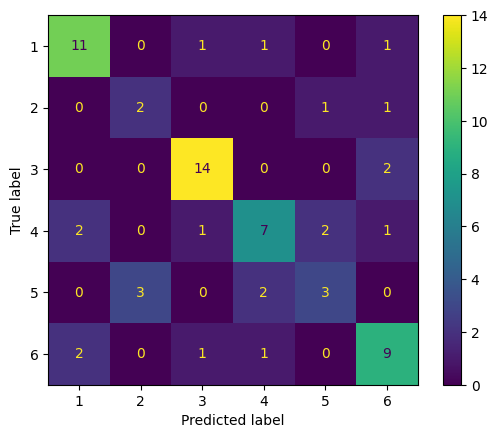

Confusion matrix:
 [[11  0  1  1  0  1]
 [ 0  2  0  0  1  1]
 [ 0  0 14  0  0  2]
 [ 2  0  1  7  2  1]
 [ 0  3  0  2  3  0]
 [ 2  0  1  1  0  9]]
Error:  0.32352941176470584


In [990]:
# Predicting
print ("Predicting")
y_pred = clf.predict(x_test)

#Get the Confusion Matrix
print ("Computing performance metrics")
results = confusion_matrix(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred, labels= clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels= clf.classes_)
disp.plot()
plt.show()
error = zero_one_loss(y_test, y_pred)
print ("Confusion matrix:\n", results)
print ("Error: ", error)

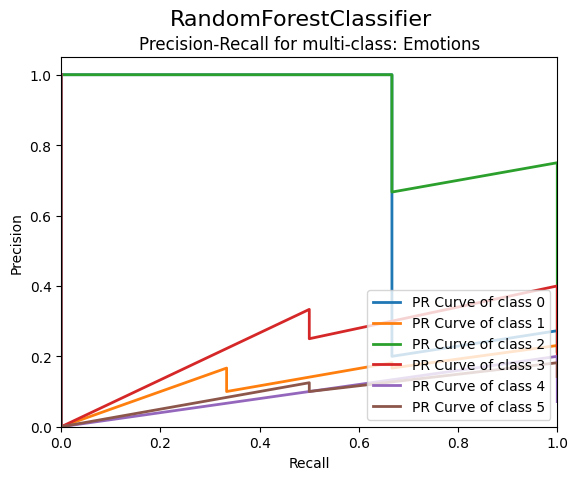

In [997]:
def calculate_classification_metrics(X, y, clf):
  # encode the target variable
  yc = np.array(y).reshape(-1, 1)
  onehotencoder = OneHotEncoder()
  yc = onehotencoder.fit_transform(yc.reshape(-1, 1)).toarray()

  # number of classes
  n_classes = yc.shape[1]

  # data split
  X_train, X_test, y_train, y_test = train_test_split(X, yc, shuffle=True, test_size=0.2)

  # fitting the model using OneVsRest strategy
  clf_ovr = OneVsRestClassifier(clf)
  clf_ovr.fit(X_train, y_train)

  # predicted probabilities
  y_proba = clf_ovr.predict_proba(X_test)

  return n_classes, y_test, y_proba

def plot_precision_recall_curve(X, y, clf, data_name):

  # call the classification function
  n_classes, y_test, y_proba = calculate_classification_metrics(X, y, clf)

  # PR curve for each class
  fig = plt.figure()
  plt.style.use('default')
  precision = dict()
  recall = dict()   # dictionaries to store the error rates for each class

  for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_proba[:, i])
    plt.plot(recall[i], precision[i], lw=2, label='PR Curve of class {}'.format(i))

  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.legend(loc="lower right", prop={'size': 10})
  plt.title('Precision-Recall for multi-class: ' + data_name)
  plt.suptitle(type(clf).__name__, fontsize=16)
  plt.show()

plot_precision_recall_curve(x_test, y_test, clf, "Emotions")

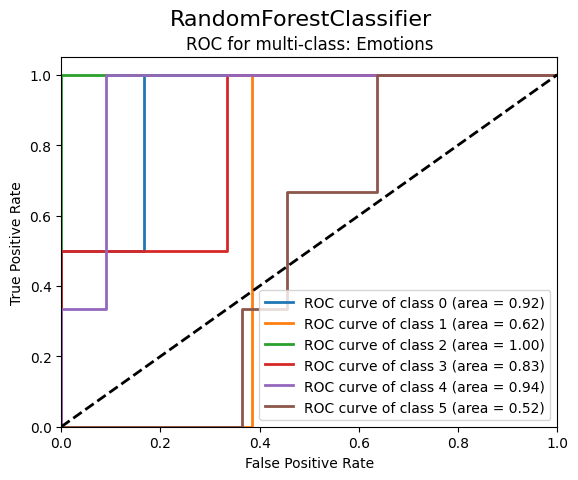

In [998]:
def plot_roc_curve(X, y, clf, data_name):

  # call the classification function
  n_classes, y_test, y_proba = calculate_classification_metrics(X, y, clf)

  # ROC curve and ROC area for each class
  fig = plt.figure()
  plt.style.use('default')
  fpr = dict()
  tpr = dict()   # dictionaries to store the error rates for each class
  roc_auc = dict()

  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

  plt.plot([0, 1], [0, 1], 'k--', lw=2)
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.legend(loc="lower right", prop={'size': 10})
  plt.title('ROC for multi-class: ' + data_name)
  plt.suptitle(type(clf).__name__, fontsize=16)
  plt.show()
plot_roc_curve(x_test, y_test, clf, "Emotions")

For the demo, it must be possible to test an individual row of the test data.

In [975]:
selectedIndex = 14
emotions = ["joy","disgust","surprise","sadness","anger","fear"]
data["emotion"] = data["emotion"].map(emotion_map)

if (len(x_test) > selectedIndex):
    testedRow = x_test.iloc[selectedIndex:selectedIndex+1]
    selectedEmotion = y_test.iloc[selectedIndex]

    prediction = clf.predict(testedRow)
    probability = clf.predict_proba(testedRow)

    print("Selected Emotion: ", emotions[selectedEmotion-1])
    print("Predicted Emotion: ", emotions[prediction[0]-1])
    print("Condfidence: ", probability.max())
    if (selectedEmotion == prediction[0]):
        print("Correct? Yes")
    else:
        print("Correct? No")

Selected Emotion:  surprise
Predicted Emotion:  surprise
Condfidence:  0.9797690272690271
Correct? Yes
